<div style="border-radius:10px; border:black solid; padding: 15px; background-color: Green; font-size:100%; text-align:left">
<p style="font-family:Georgia; font-weight:bold; letter-spacing: 2px; color:white; font-size:200%; text-align:center;padding: 0px;"> Banking Churn Analysis & Modeling.</p></div>

<div align="center">
  <img src="https://m.economictimes.com/thumb/msid-100281493,width-1200,height-900,resizemode-4,imgsize-14062/banks-request-rbi-for-more-time-for-new-loan-provisioning-system.jpg" alt="Image Description" width="300" height="200">
</div>

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color: ##F0E68C ; font-size:100%; text-align:left">

<h3 align="left"><font color=brown>📊 Business Objective:</font></h3>
   
- The goal would be to identify which customers are most likely to churn (leave the service) and understand the key factors driving their decision to leave. `Churn Reduction through Predictive Analytics`
- Churn refers to the process by which a customer stops doing business with a company.

<h3 align="left"><font color=brown>📊 Business Value:</font></h3>
- Customer retention is critical for a bank’s profitability. Predicting which customers are likely to churn can help the bank take proactive steps (e.g., offering personalized services or incentives) to retain valuable customers.

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color: ##F0E68C ; font-size:100%; text-align:left">

<h3 align="left"><font color=brown>📊 NOTE:</font></h3>
Don't run the script in the same cell of output, create a new cell for the each step.

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

## **Import Needded Columns**

## **Data Representation**

- **You can find the dataset on this [link](https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling)**

In [99]:
df=pd.read_csv('Churn_Modelling.csv')

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


* **RowNumber**: Index of the row.
* **CustomerId**: Unique identifier for each customer.
* **Surname**: Customer's last name (may not be very useful for analysis).
* **CreditScore**: The credit score of the customer [300 : 850].
    - Poor credit: 300 to 579.
    - Fair credit: 580 to 669.
    - Good credit: 670 to 739.
    - Very good credit: 740 to 799.
    - Excellent credit: 800 to 850.
* **Geography**: Country of the customer (e.g., France, Spain).
* **Gender**: Gender of the customer (e.g., Male, Female).
* **Age**: Age of the customer.
* **Tenure**: Number of years the customer has been with the bank.
* **Balance**: Account balance of the customer.
* **NumOfProducts**: Number of products the customer has purchased.
* **HasCrCard**: Whether the customer has a credit card (1 = Yes, 0 = No).
* **IsActiveMember**: Whether the customer is an active member (1 = Yes, 0 = No).
* **EstimatedSalary**: Estimated annual salary of the customer.
* **Exited**: Whether the customer left the bank (1 = Yes, 0 = No) — this is likely the target for churn prediction.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


## **Data Wrangling**

**Check Duplicated Values**

In [5]:
df.duplicated().sum()

np.int64(0)

**Check Missing Values**

In [6]:
df.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


**Check Outliers Values**

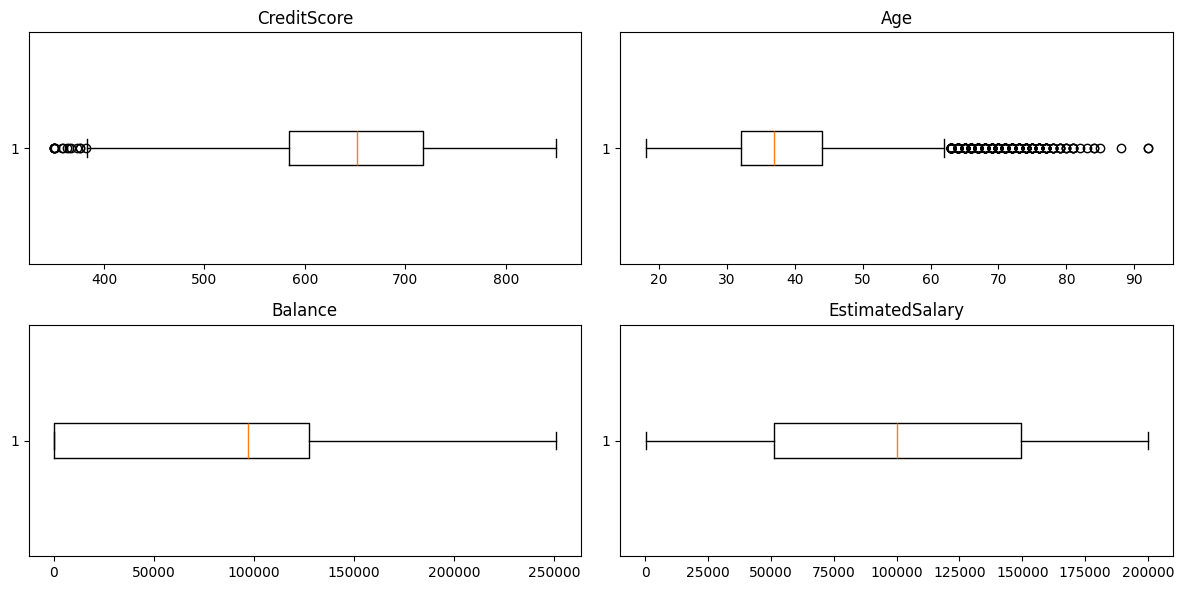

In [11]:

plt.figure(figsize=(12, 6))

plt.subplot(2,2,1)
plt.boxplot(df['CreditScore'],vert=False)
plt.title('CreditScore')

plt.subplot(2,2,2)
plt.boxplot(df['Age'],vert=False)
plt.title('Age')

plt.subplot(2,2,3)
plt.boxplot(df['Balance'],vert=False)
plt.title('Balance')

plt.subplot(2,2,4)
plt.boxplot(df['EstimatedSalary'],vert=False)
plt.title('EstimatedSalary')

plt.tight_layout()
plt.show()


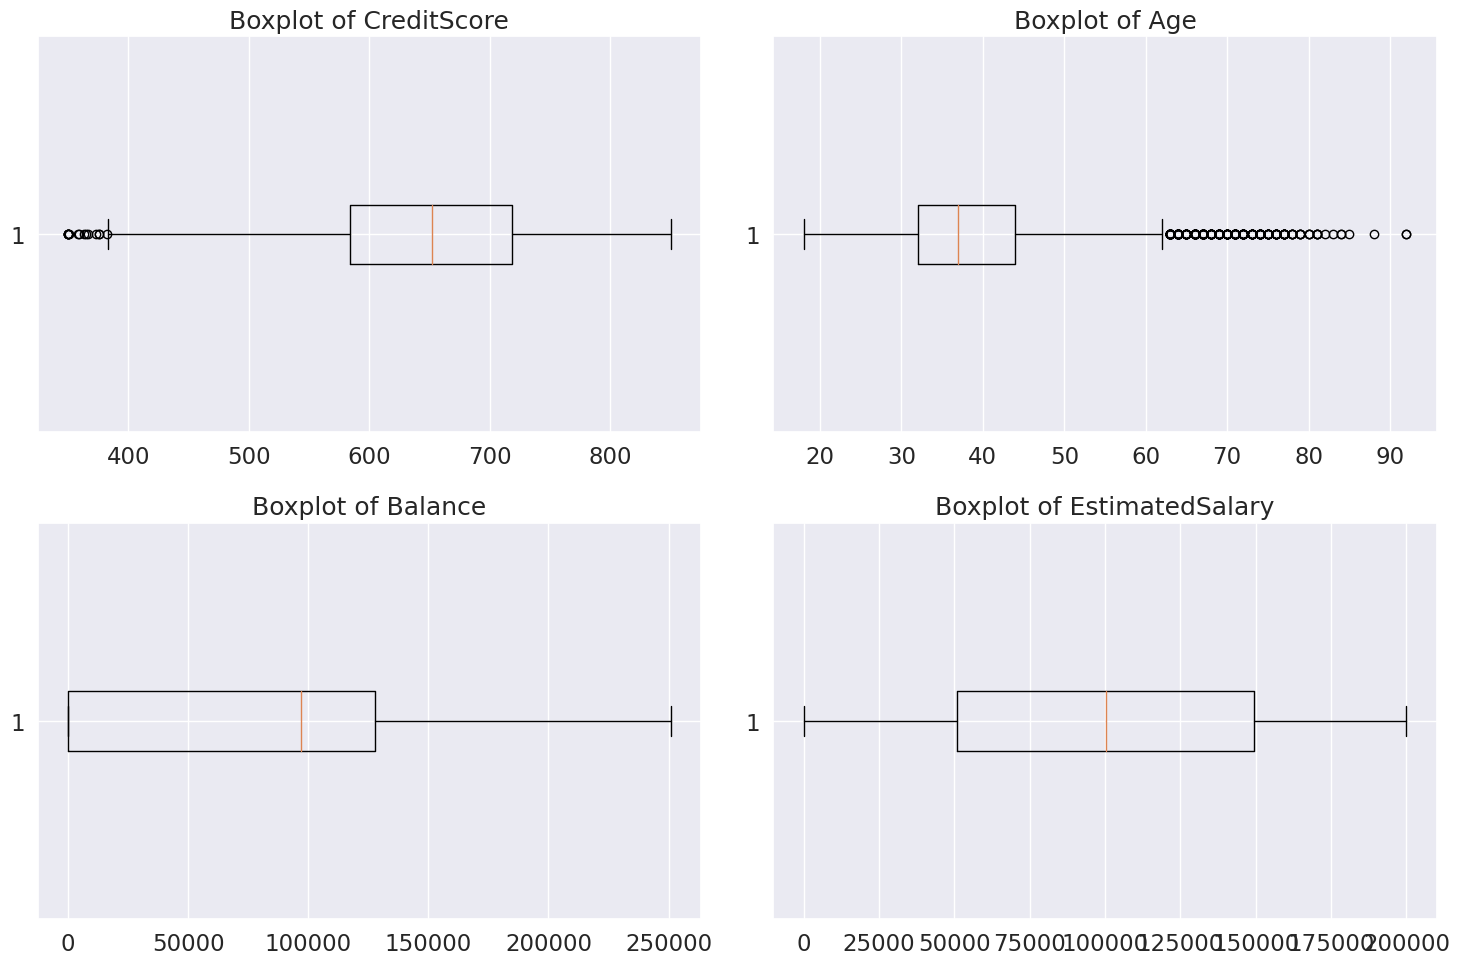

## **Exploratory Data Analysis**

- **The goal of EDA is to better understand the distributions of features, identify trends or patterns, and explore relationships between features and the target variable (Exited)**

#### **Univariate Analysis**

**CreditScore Column**

In [13]:
df['CreditScore'].describe()

,CreditScore
count,10000.000000
mean,650.528800
std,96.653299
min,350.000000
25%,584.000000
50%,652.000000
75%,718.000000
max,850.000000


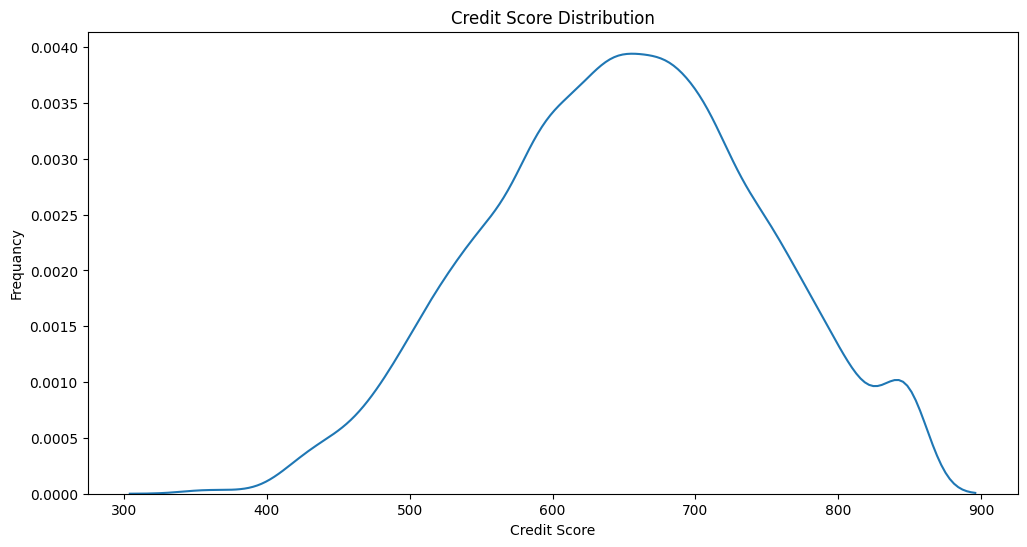

In [17]:
plt.figure(figsize=(12, 6))
sns.kdeplot(df['CreditScore'])
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Frequancy')
plt.show()

- The distribution of credit scores is slightly skewed to the right, meaning more customers have higher credit scores (closer to 800).
- This could indicate that most customers have a good credit history.

**Geography Column**

In [18]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


/tmp/ipython-input-1508707562.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i,cats[i]+3,cats[i],ha='center')


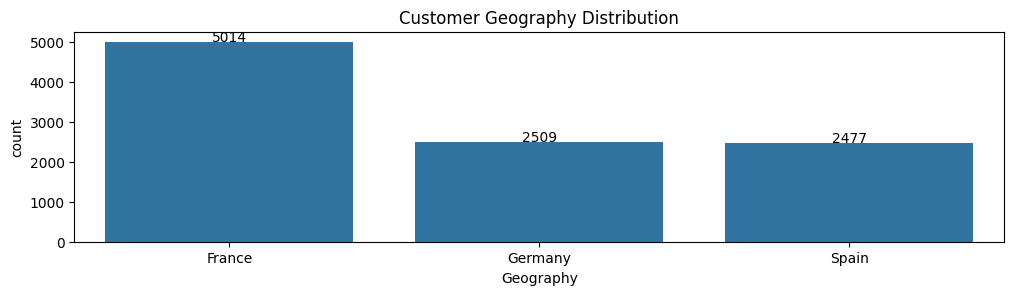

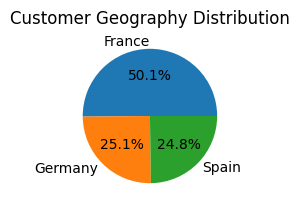

In [24]:
plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
cats=df['Geography'].value_counts()
percentages=df['Geography'].value_counts(normalize=True)
sns.barplot(x=cats.index,y=cats.values)
for i in range(len(cats)):
  plt.text(i,cats[i]+3,cats[i],ha='center')

plt.title('Customer Geography Distribution')
plt.xlabel('Geography')
plt.ylabel('count')
plt.show()



plt.subplot(2,1,2)
plt.pie(percentages,autopct='%1.1f%%',labels=percentages.index)
plt.title('Customer Geography Distribution')
plt.show()

**Gender Column**

In [25]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


/tmp/ipython-input-2960096193.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i,cats[i]+3,cats[i],ha='center')


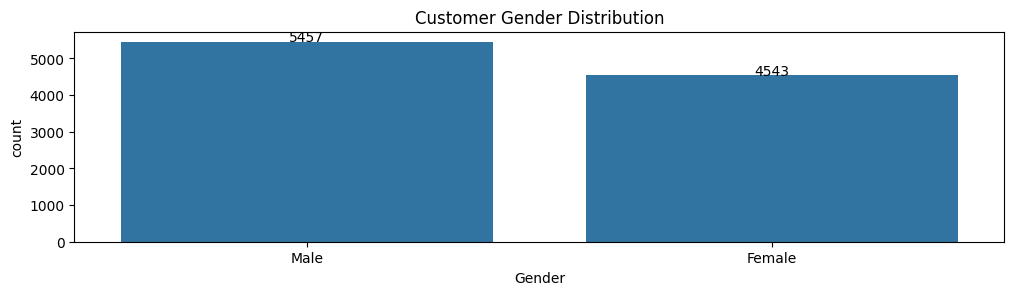

Text(0.5, 1.0, 'Customer Gender Distribution')

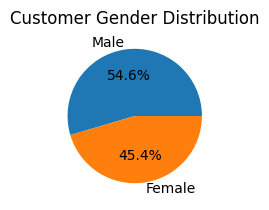

In [26]:
plt.figure(figsize=(12, 6))

plt.subplot(2,1,1)
cats=df['Gender'].value_counts()
percentages=df['Gender'].value_counts(normalize=True)
sns.barplot(x=cats.index,y=cats.values)
for i in range(len(cats)):
  plt.text(i,cats[i]+3,cats[i],ha='center')

plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('count')
plt.show()

plt.subplot(2,1,2)
plt.pie(percentages,labels=percentages.index,autopct='%1.1f%%')
plt.title('Customer Gender Distribution')

**Age Column**

In [27]:
df['Age'].describe()

,Age
count,10000.000000
mean,38.921800
std,10.487806
min,18.000000
25%,32.000000
50%,37.000000
75%,44.000000
max,92.000000


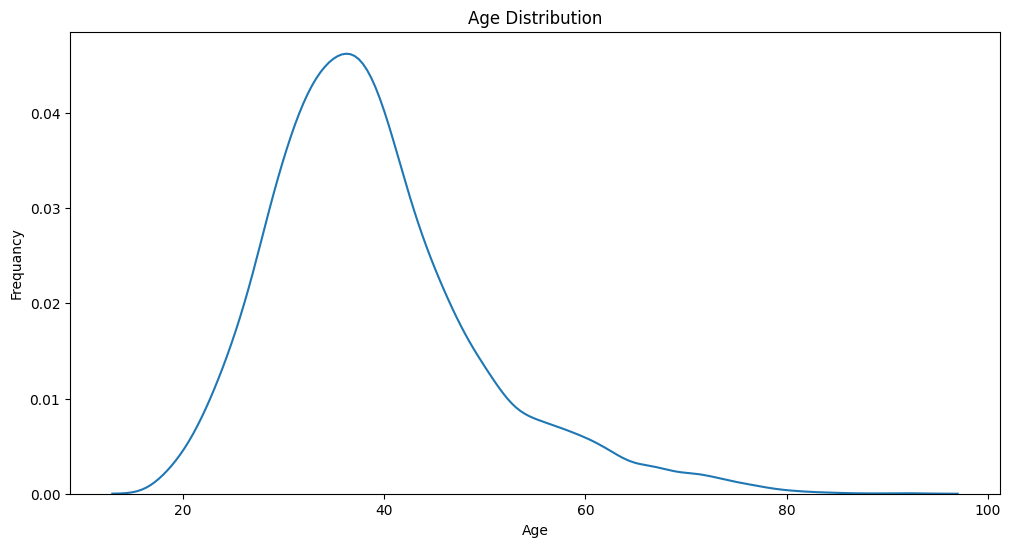

In [28]:
plt.figure(figsize=(12, 6))
sns.kdeplot(df['Age'])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequancy')
plt.show()

- The age distribution is concentrated around 30–50 years, with fewer customers in the older age range.
- This suggests that most customers are middle-aged, which might be relevant depending on the bank’s target demographic.

**Tenure Column**

In [32]:
df['Tenure'].value_counts()

,count
Tenure,
2,1048
1,1035
7,1028
8,1025
5,1012
3,1009
4,989
9,984
6,967


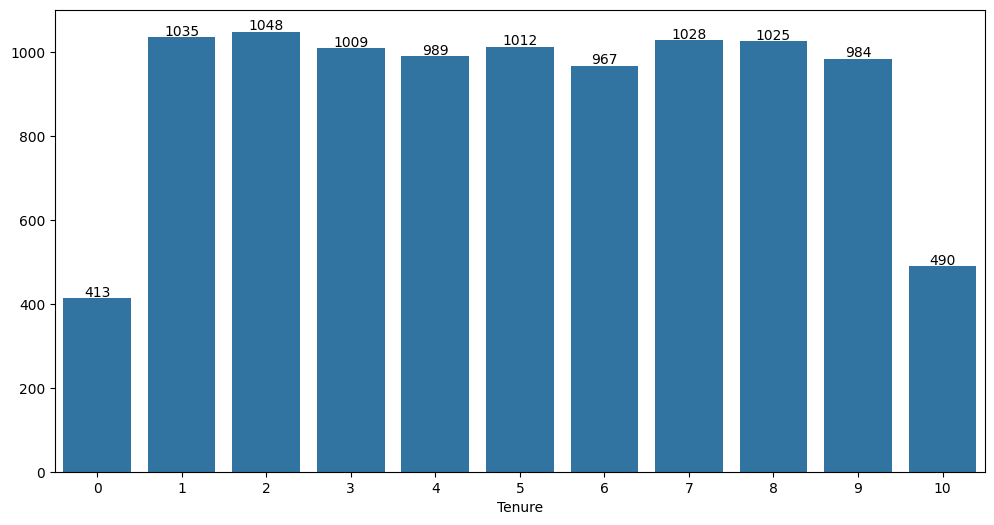

In [36]:
plt.figure(figsize=(12, 6))
cats=df['Tenure'].value_counts()
sns.barplot(x=cats.index,y=cats.values)
for i in range(len(cats)):
  plt.text(i,cats[i]+4,cats[i],ha='center')

- The uniform distribution suggests that the bank has a balanced customer base across different tenure lengths.

**Balance Column**

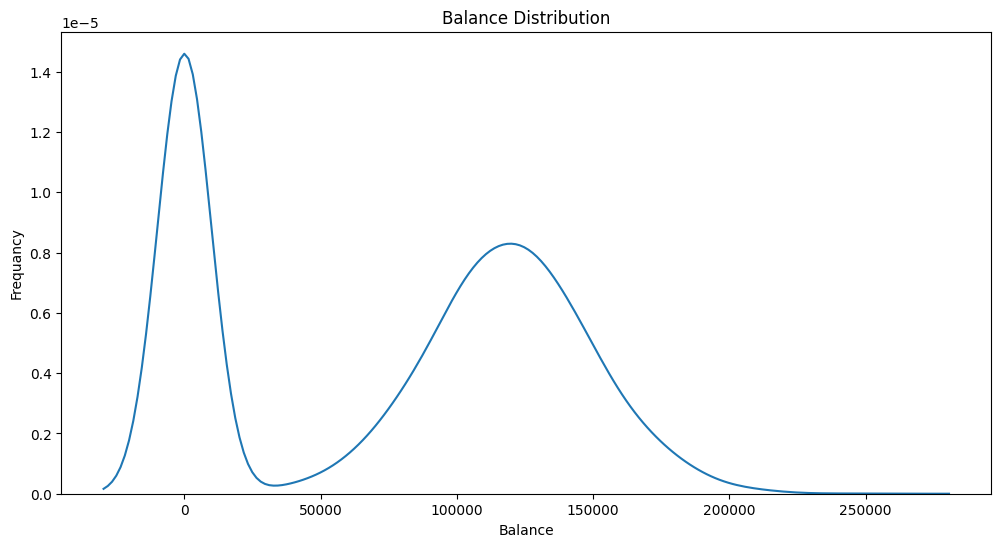

In [37]:
plt.figure(figsize=(12, 6))
sns.kdeplot(df['Balance'])
plt.title('Balance Distribution')
plt.xlabel('Balance')
plt.ylabel('Frequancy')
plt.show()

- A bimodal distribution in the Balance column suggests two distinct customer segments:
  - Low-balance customers who may be more likely to churn.
  - High-balance customers who are likely more engaged and loyal.

**NumOfProducts Column**

In [38]:
df['NumOfProducts'].value_counts()

,count
NumOfProducts,
1,5084
2,4590
3,266
4,60


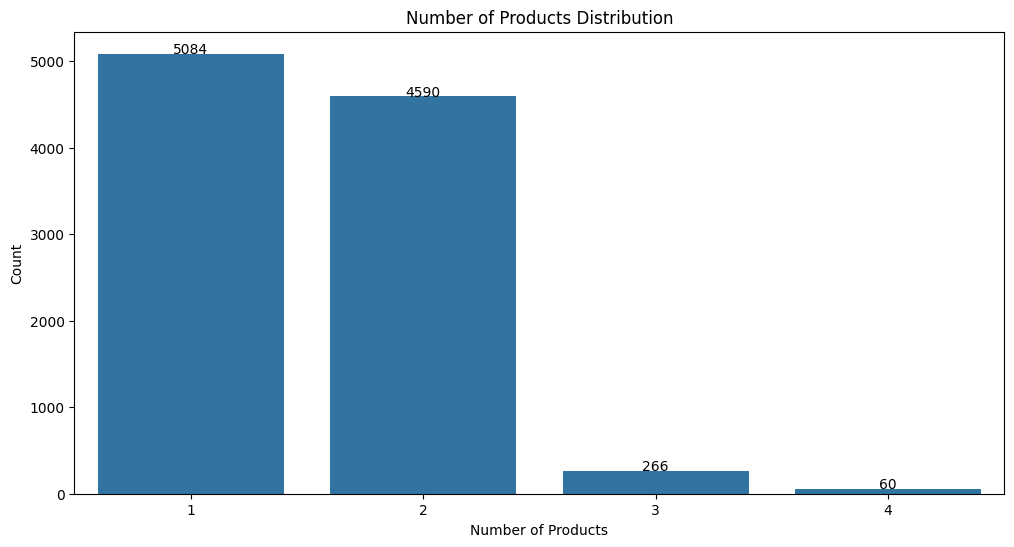

In [47]:
plt.figure(figsize=(12,6))
cats=df['NumOfProducts'].value_counts()
sns.barplot(x=cats.index,y=cats.values)
for i in range(len(cats)):
  plt.text(i,cats.values[i]+3,cats.values[i],ha='center')
plt.title('Number of Products Distribution')
plt.xlabel('Number of Products')
plt.ylabel('Count')
plt.show()

**HasCrCard Column**

In [48]:
df['HasCrCard'].value_counts()

,count
HasCrCard,
1,7055
0,2945


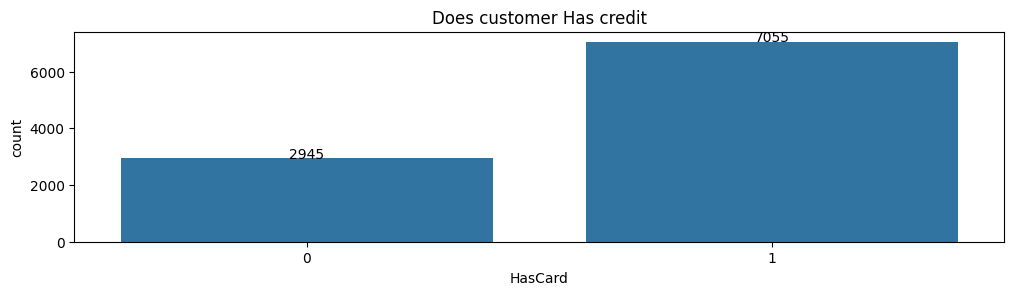

Text(0.5, 1.0, 'Does customer has card')

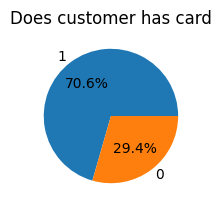

In [49]:
plt.figure(figsize=(12, 6))

plt.subplot(2,1,1)
cats=df['HasCrCard'].value_counts()
percentages=df['HasCrCard'].value_counts(normalize=True)
sns.barplot(x=cats.index,y=cats.values)
for i in range(len(cats)):
  plt.text(i,cats[i]+3,cats[i],ha='center')

plt.title('Does customer Has credit')
plt.xlabel('HasCard')
plt.ylabel('count')
plt.show()

plt.subplot(2,1,2)
plt.pie(percentages,labels=percentages.index,autopct='%1.1f%%')
plt.title('Does customer has card')

**IsActiveMember Column**

In [50]:
df['IsActiveMember'].value_counts()

,count
IsActiveMember,
1,5151
0,4849


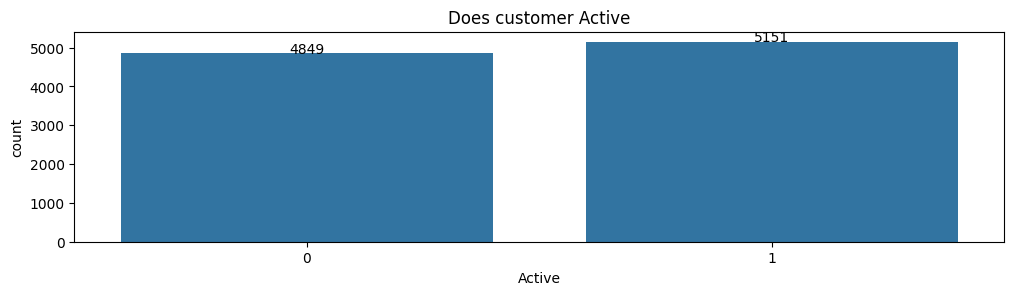

Text(0.5, 1.0, 'Does customer Active')

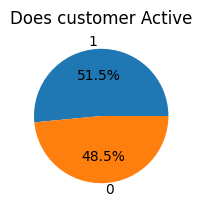

In [52]:
plt.figure(figsize=(12, 6))

plt.subplot(2,1,1)
cats=df['IsActiveMember'].value_counts()
percentages=df['IsActiveMember'].value_counts(normalize=True)
sns.barplot(x=cats.index,y=cats.values)
for i in range(len(cats)):
  plt.text(i,cats[i]+3,cats[i],ha='center')

plt.title('Does customer Active')
plt.xlabel('Active')
plt.ylabel('count')
plt.show()

plt.subplot(2,1,2)
plt.pie(percentages,labels=percentages.index,autopct='%1.1f%%')
plt.title('Does customer Active')

In [53]:
df['EstimatedSalary'].describe()

,EstimatedSalary
count,10000.000000
mean,100090.239881
std,57510.492818
min,11.580000
25%,51002.110000
50%,100193.915000
75%,149388.247500
max,199992.480000


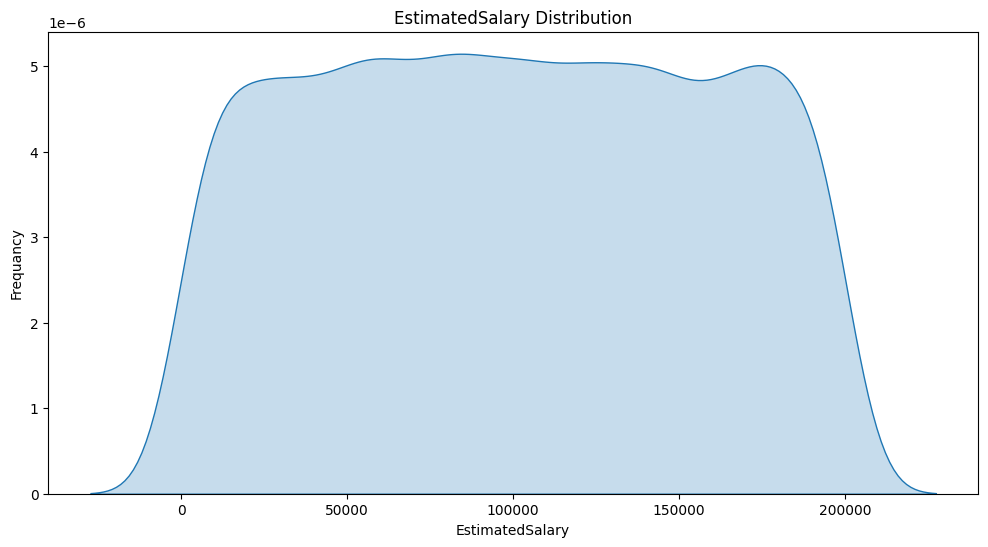

In [55]:
from pickle import TRUE
plt.figure(figsize=(12, 6))
sns.kdeplot(df['EstimatedSalary'],fill=TRUE)
plt.title('EstimatedSalary Distribution')
plt.xlabel('EstimatedSalary')
plt.ylabel('Frequancy')
plt.show()

**Exited Column**

In [56]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


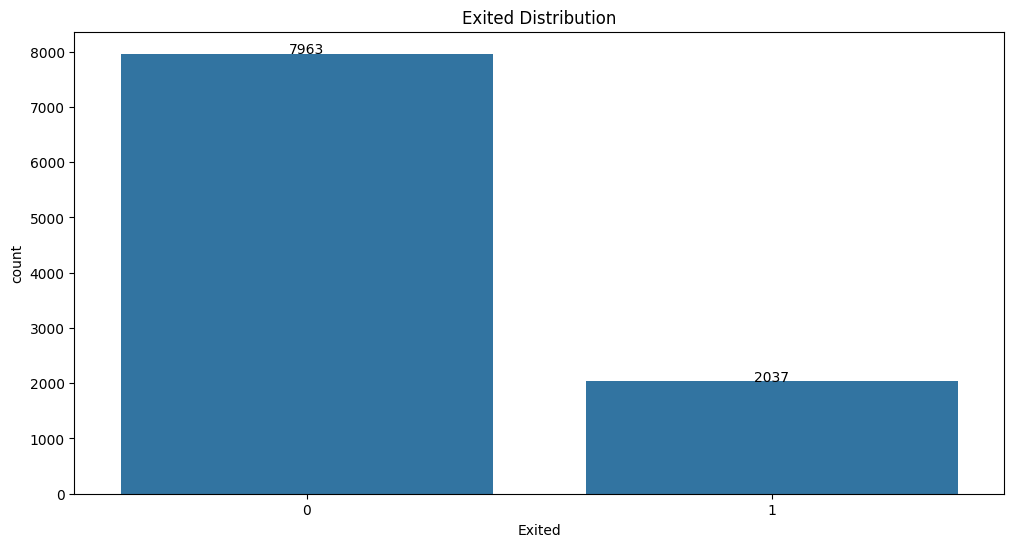

Text(0.5, 1.0, 'Exited Distribution')

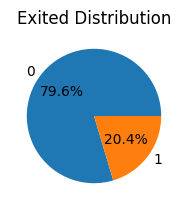

In [57]:
plt.figure(figsize=(12, 6))
cats=df['Exited'].value_counts()
percentages=df['Exited'].value_counts(normalize=True)
sns.barplot(x=cats.index,y=cats.values)
for i in range(len(cats)):
  plt.text(i,cats[i]+3,cats[i],ha='center')
plt.title('Exited Distribution')
plt.xlabel('Exited')
plt.ylabel('count')
plt.show()
plt.subplot(2,1,2)
plt.pie(percentages,labels=percentages.index,autopct='%1.1f%%')
plt.title('Exited Distribution')

#### **Bivariate Analysis**

**Numerical Features vs. Churn (Exited)**

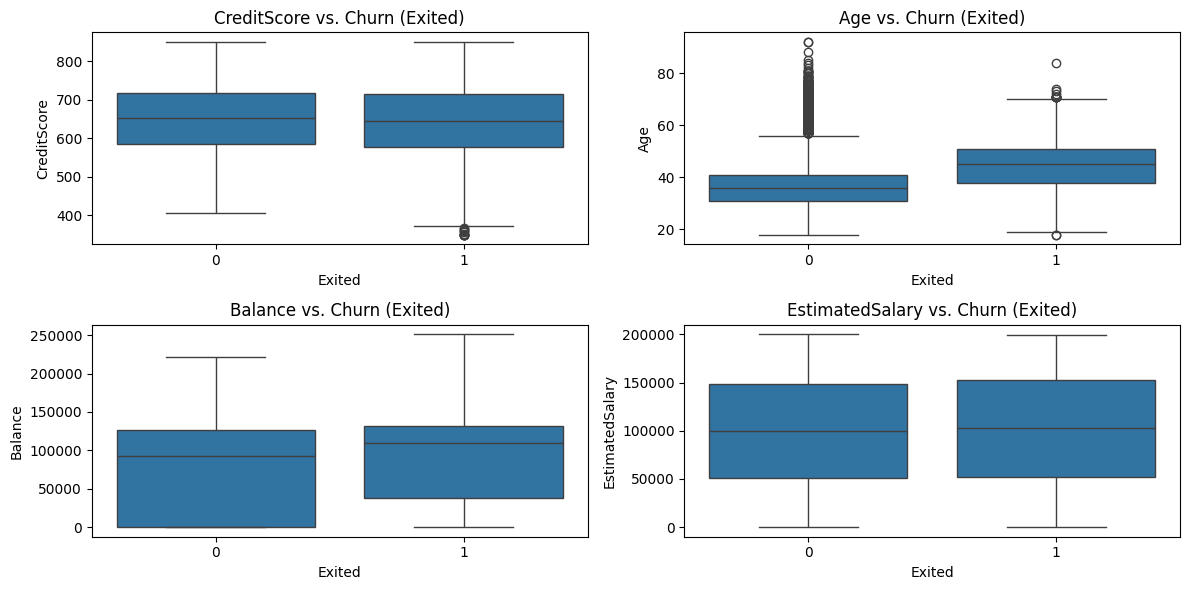

In [60]:
plt.figure(figsize=(12, 6))

plt.subplot(2,2,1)
sns.boxplot(x=df['Exited'],y=df['CreditScore'])
plt.title('CreditScore vs. Churn (Exited)')

plt.subplot(2,2,2)
sns.boxplot(x=df['Exited'],y=df['Age'])
plt.title('Age vs. Churn (Exited)')

plt.subplot(2,2,3)
sns.boxplot(x=df['Exited'],y=df['Balance'])
plt.title('Balance vs. Churn (Exited)')

plt.subplot(2,2,4)
sns.boxplot(x=df['Exited'],y=df['EstimatedSalary'])
plt.title('EstimatedSalary vs. Churn (Exited)')

plt.tight_layout()
plt.show()

**Categorical Features vs. Churn (Exited)**

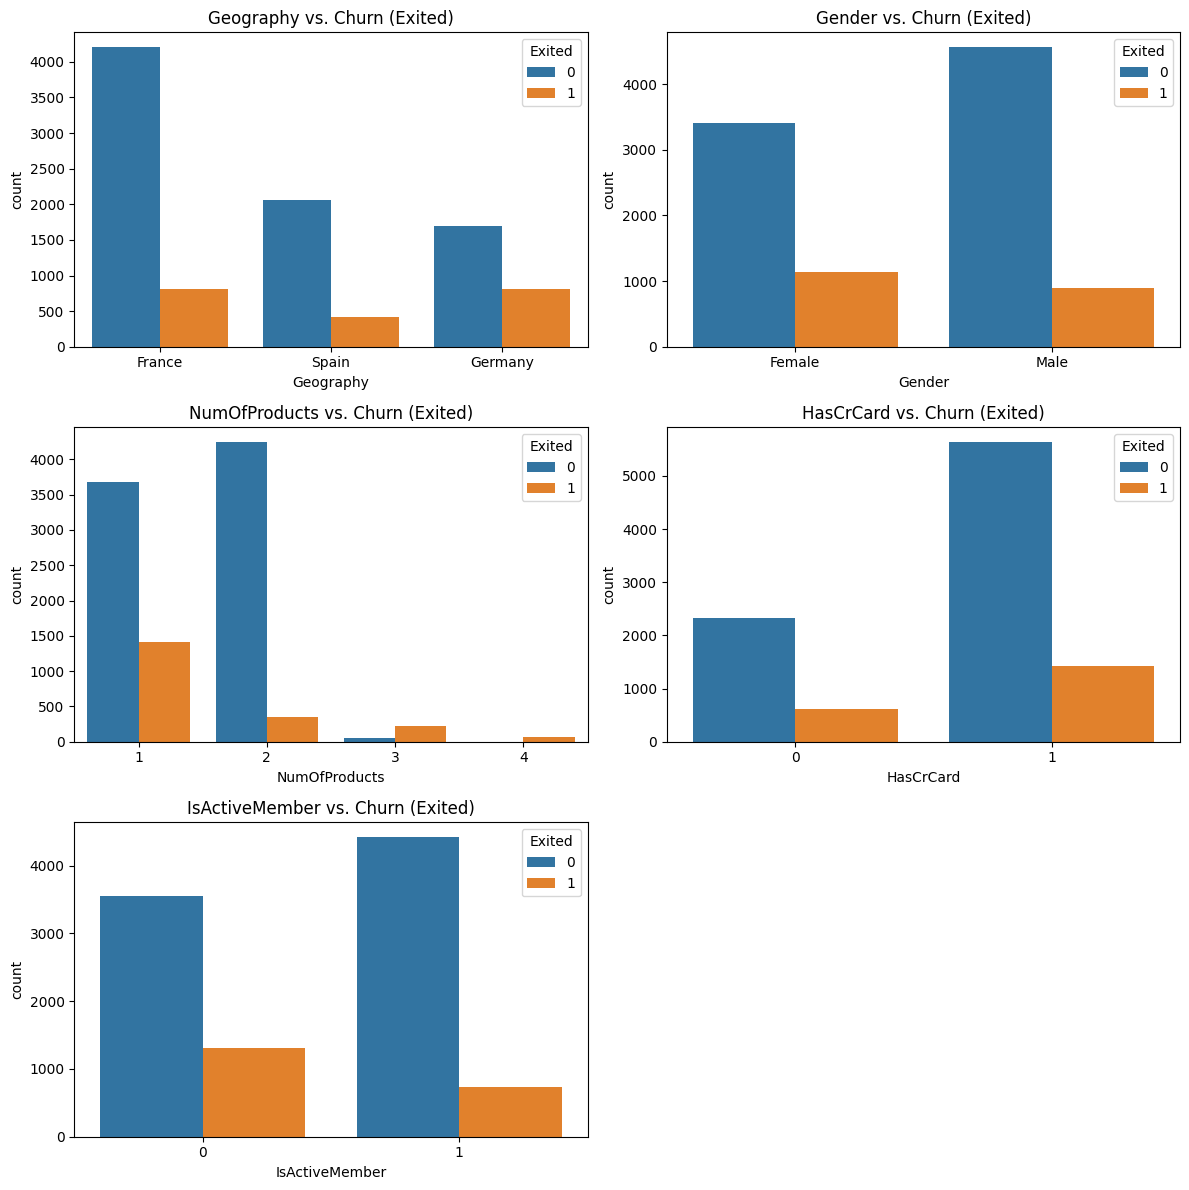

In [71]:
plt.figure(figsize=(12, 12))

plt.subplot(3,2,1)
sns.countplot(x=df['Geography'],hue=df['Exited'])
plt.title('Geography vs. Churn (Exited)')
plt.xlabel('Geography')
plt.ylabel('count')


plt.subplot(3,2,2)
sns.countplot(x=df['Gender'],hue=df['Exited'])
plt.title('Gender vs. Churn (Exited)')
plt.xlabel('Gender')
plt.ylabel('count')


plt.subplot(3,2,3)
sns.countplot(x=df['NumOfProducts'],hue=df['Exited'])
plt.title('NumOfProducts vs. Churn (Exited)')
plt.xlabel('NumOfProducts')
plt.ylabel('count')


plt.subplot(3,2,4)
sns.countplot(x=df['HasCrCard'],hue=df['Exited'])
plt.title('HasCrCard vs. Churn (Exited)')
plt.xlabel('HasCrCard')
plt.ylabel('count')

plt.subplot(3,2,5)
sns.countplot(x=df['IsActiveMember'],hue=df['Exited'])
plt.title('IsActiveMember vs. Churn (Exited)')
plt.xlabel('IsActiveMember')
plt.ylabel('count')

plt.tight_layout()

plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

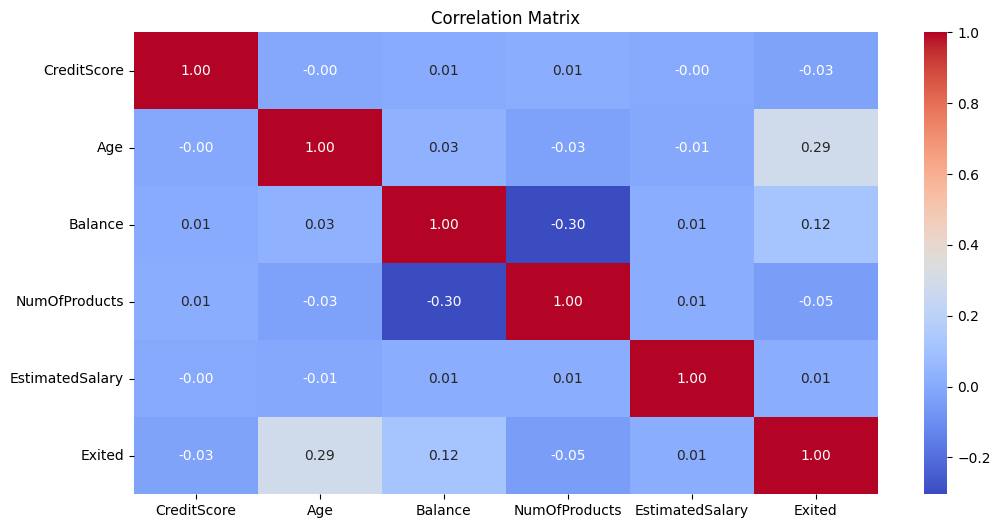

In [75]:
cols=['CreditScore','Age','Balance','NumOfProducts','EstimatedSalary','Exited']
orr=df[cols].corr()
plt.figure(figsize=(12, 6))
sns.heatmap(orr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix')

**Multivariate Analysis**

## **Data Preprocessing**

**Drop Unneeded Columns**

In [100]:
df=df.drop(columns=['RowNumber','CustomerId','Surname'])

**Define Features `X` and Target `y`**

In [107]:
x=df.drop(columns=['Exited'])
y=df['Exited']

**Data Encoding**

**To apply encoding to categorical columns in your dataset, the type of encoding will depend on whether the categorical variables are nominal (unordered) or ordinal (ordered)**

In [108]:
x = pd.get_dummies(x, columns=['Geography', 'Gender'])


In [109]:
x.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,True,False,False,True,False
1,608,41,1,83807.86,1,0,1,112542.58,False,False,True,True,False
2,502,42,8,159660.80,3,1,0,113931.57,True,False,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,True,False,False,True,False
4,850,43,2,125510.82,1,1,1,79084.10,False,False,True,True,False


**Data Scaling**

In [110]:
scaler=StandardScaler()
x=scaler.fit_transform(x)

**Data Splitting**

In [112]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

**Data Balancing**
- We can apply SMOTE model to balance the data.

In [113]:
smote=SMOTE(random_state=42)
Resampled_x_train,Resampled_y_train=smote.fit_resample(x_train,y_train)

In [114]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", Resampled_y_train.value_counts())


Before SMOTE: Exited
0    6356
1    1644
Name: count, dtype: int64
After SMOTE: Exited
0    6356
1    6356
Name: count, dtype: int64


## **Machine Learning Models**

**Logistic Regression model**

In [ ]:
lr =

# Train the model


LogisticRegression(max_iter=1000)

In [ ]:
# Train Score


0.7348961611076148


In [ ]:
# Test Score


0.739


In [ ]:
# Make predictions on the test set
y_pred = lr.predict(X_test)

In [ ]:
# Get our metrics
lr_acc = accuracy_score(y_test, y_pred)
lr_per = precision_score(y_test, y_pred)
lr_rec = recall_score(y_test, y_pred)

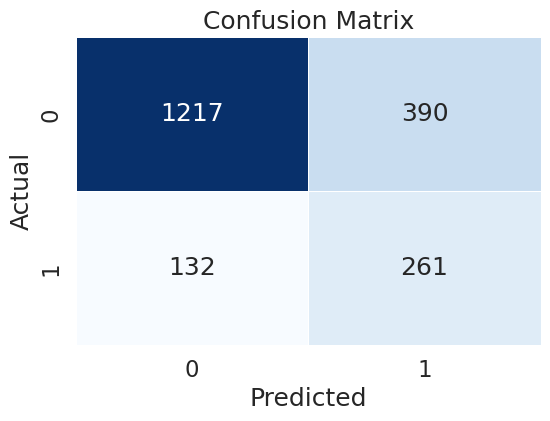

In [ ]:
# Create a confusion matrix

# Visualize the confusion matrix with a heatmap

**SVC Model**

In [ ]:
# Define hyperparameter grid


In [ ]:
# Perform Grid Search with cross-validation


GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10],
                         'kernel': ['linear', 'poly', 'rbf']})

In [ ]:
# Get best model
best_model =

SVC(C=10)

In [ ]:
# Train Score


0.7507079924480805


In [ ]:
# Test Score


0.882


In [ ]:
# Make predictions on the test set
y_pred = best_model.predict(X_test)

In [ ]:
# Get our metrics
svc_acc = accuracy_score(y_test, y_pred)
svc_per = precision_score(y_test, y_pred)
svc_rec = recall_score(y_test, y_pred)

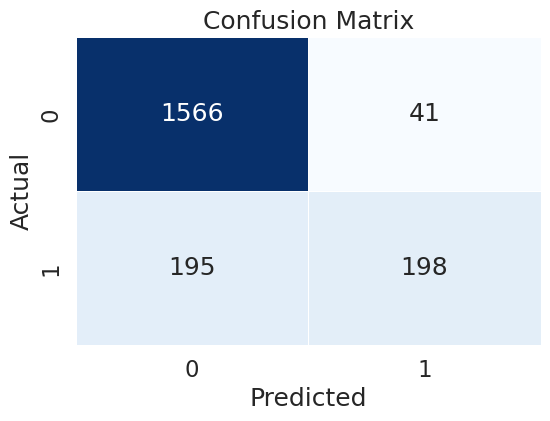

In [ ]:
# Create a confusion matrix


**K-Neighbors Classifier**

In [ ]:
knn =

# Train the model


KNeighborsClassifier(n_neighbors=3)

In [ ]:
# Train Score

0.9323473882945249


In [ ]:
# Test Score

0.7705


In [ ]:
# Make predictions on the test set
y_pred = knn.predict(X_test)

In [ ]:
# Get our metrics
knn_acc = accuracy_score(y_test, y_pred)
knn_per = precision_score(y_test, y_pred)
knn_rec = recall_score(y_test, y_pred)

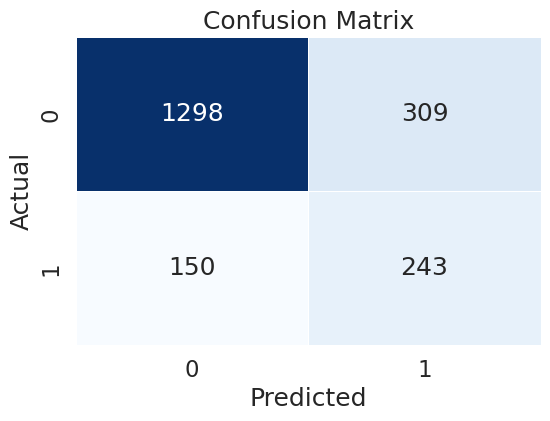

In [ ]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)


**Decision Tree Classifier**

In [ ]:
clf =
# Train the model


DecisionTreeClassifier(max_depth=4, min_impurity_decrease=0.01, random_state=42)

In [ ]:
# Train Score


0.7178256765261171


In [ ]:
# Test Score


0.743


In [ ]:
# Make predictions on the test set
y_pred = clf.predict(X_test)

In [ ]:
# Get our metrics
clf_acc = accuracy_score(y_test, y_pred)
clf_per = precision_score(y_test, y_pred)
clf_rec = recall_score(y_test, y_pred)

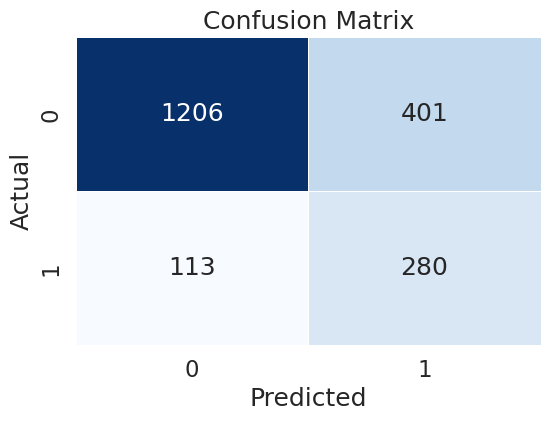

In [ ]:
# Create a confusion matrix


**RandomForestClassifier Model**

In [ ]:
RF_classifier =

RandomForestClassifier(min_impurity_decrease=0.01)

In [ ]:
# Train score


0.7624292007551919

In [ ]:
# Test score


0.7925

In [ ]:
# Get prediction
y_pred = RF_classifier.predict(X_test)

In [ ]:
# Get our metrics
rf_acc = accuracy_score(y_test, y_pred)
rf_per = precision_score(y_test, y_pred)
rf_rec = recall_score(y_test, y_pred)

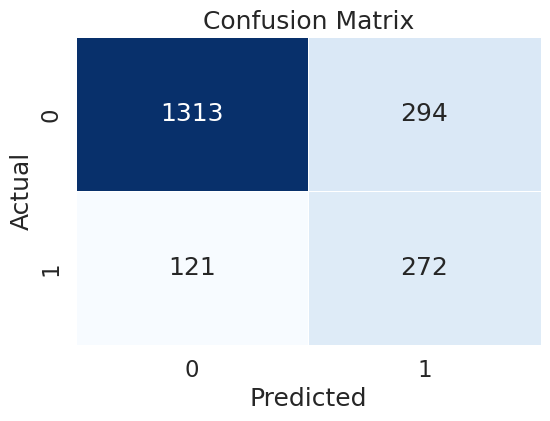

In [ ]:
# Create a confusion matrix

# Visualize the confusion matrix with a heatmap


**Bagging Classifier**

In [ ]:
# Create a base classifier
base_classifier =

# Create a bagging classifier
bagged_classifier =

# Train the bagged classifier on your data
bagged_classifier.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(min_impurity_decrease=0.01))

In [ ]:
# Train Score

0.736626809314034

In [ ]:
# Test Score

0.743

In [ ]:
# Make predictions
y_pred = bagged_classifier.predict(X_test)

In [ ]:
# Get our metrics
bag_acc = accuracy_score(y_test, y_pred)
bag_per = precision_score(y_test, y_pred)
bag_rec = recall_score(y_test, y_pred)

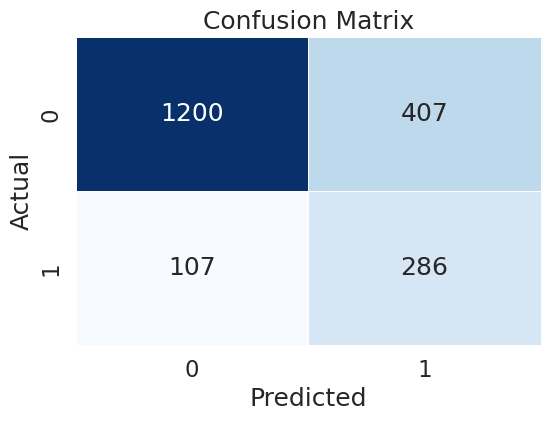

In [ ]:
# Create a confusion matrix

# Visualize the confusion matrix with a heatmap


**ExtraTreesClassifier**

In [ ]:
# ExtraTreeClassifier Model
ET_classifier =

ExtraTreesClassifier(min_impurity_decrease=0.01)

In [ ]:
# Train score


0.7583385777218377

In [ ]:
# Test score


0.7415

In [ ]:
# Get prediction
y_pred_et = ET_classifier.predict(X_test)

In [ ]:
# Get our metrics
et_acc = accuracy_score(y_test, y_pred_et)
et_per = precision_score(y_test, y_pred_et)
et_rec = recall_score(y_test, y_pred_et)

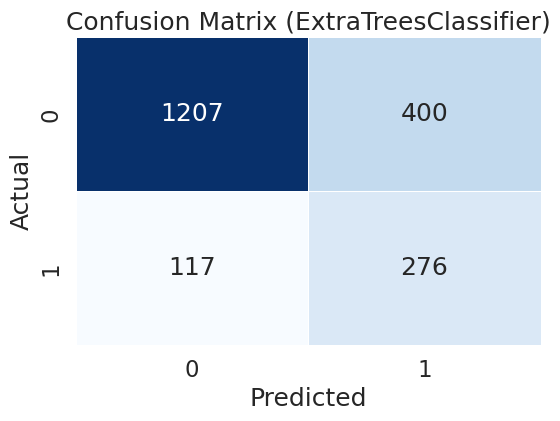

In [ ]:
# Create a confusion matrix for ExtraTreeClassifier


**AdaBoostClassifier**

In [ ]:
# Create AdaBoostClassifier Model
AB_classifier =

AdaBoostClassifier(n_estimators=100)

In [ ]:
# Train score


0.8422750157331655

In [ ]:
# Test score


0.815

In [ ]:
# Get prediction
y_pred_ab = AB_classifier.predict(X_test)

In [ ]:
# Get our metrics
ada_acc = accuracy_score(y_test, y_pred_ab)
ada_per = precision_score(y_test, y_pred_ab)
ada_rec = recall_score(y_test, y_pred_ab)

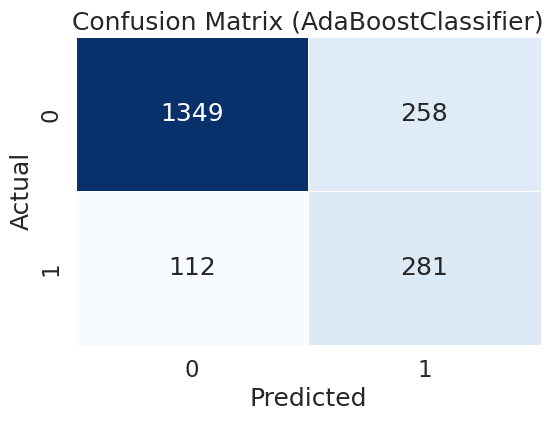

In [ ]:
# Create a confusion matrix for AdaBoostClassifier

# Visualize the confusion matrix with a heatmap


**XGBClassifier Model**

In [ ]:
# Create XGBClassifier Model
XGB_classifier =

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
# Train score


0.9907960981749528

In [ ]:
# Test score


0.85

In [ ]:
# Get prediction


In [ ]:
# Get our metrics
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_per = precision_score(y_test, y_pred_xgb)
xgb_rec = recall_score(y_test, y_pred_xgb)

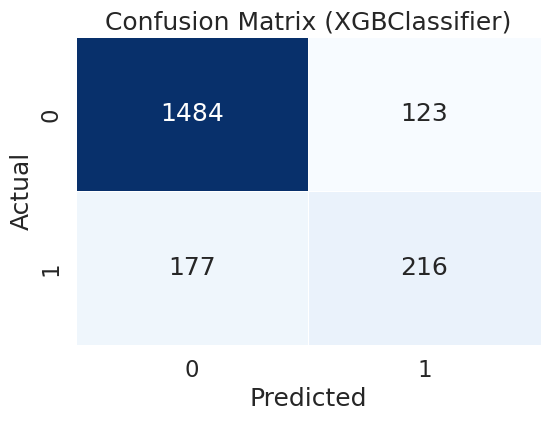

In [ ]:
# Create a confusion matrix for XGBClassifier
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)


**CatBoostClassifier**

In [ ]:
# Create CatBoostClassifier Model
CatBoost_classifier =

0:	learn: 0.6558264	total: 53ms	remaining: 5.25s
1:	learn: 0.6255098	total: 55.9ms	remaining: 2.74s
2:	learn: 0.5982137	total: 58.8ms	remaining: 1.9s
3:	learn: 0.5770465	total: 61.7ms	remaining: 1.48s
4:	learn: 0.5574065	total: 64.6ms	remaining: 1.23s
5:	learn: 0.5409075	total: 67.4ms	remaining: 1.06s
6:	learn: 0.5286027	total: 70.9ms	remaining: 941ms
7:	learn: 0.5175869	total: 73.8ms	remaining: 849ms
8:	learn: 0.5075540	total: 76.7ms	remaining: 776ms
9:	learn: 0.4978899	total: 79.9ms	remaining: 719ms
10:	learn: 0.4893601	total: 83.3ms	remaining: 674ms
11:	learn: 0.4823757	total: 86.3ms	remaining: 633ms
12:	learn: 0.4765071	total: 89.3ms	remaining: 598ms
13:	learn: 0.4699199	total: 92.3ms	remaining: 567ms
14:	learn: 0.4641558	total: 95.5ms	remaining: 541ms
15:	learn: 0.4591026	total: 99.3ms	remaining: 521ms
16:	learn: 0.4556528	total: 103ms	remaining: 502ms
17:	learn: 0.4506462	total: 106ms	remaining: 483ms
18:	learn: 0.4472239	total: 109ms	remaining: 465ms
19:	learn: 0.4445149	total: 

In [ ]:
# Train score


0.8654027690371303

In [ ]:
# Test score


0.8415

In [ ]:
# Get prediction


In [ ]:
# Get our metrics
cat_acc = accuracy_score(y_test, y_pred_catboost)
cat_per = precision_score(y_test, y_pred_catboost)
cat_rec = recall_score(y_test, y_pred_catboost)

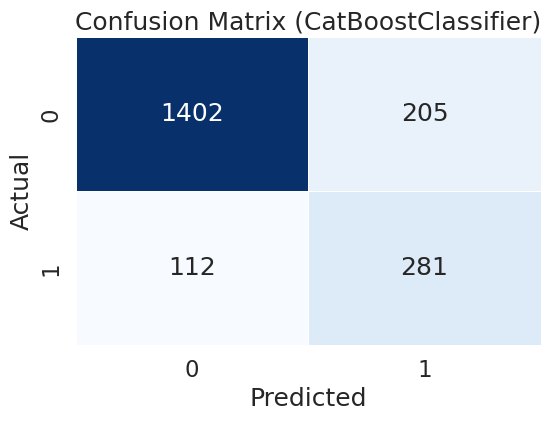

In [ ]:
# Create a confusion matrix for CatBoostClassifier


**LGBMClassifier**

In [ ]:
# Create LGBMClassifier Model
LGBM_classifier

[LightGBM] [Info] Number of positive: 6356, number of negative: 6356
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001511 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1294
[LightGBM] [Info] Number of data points in the train set: 12712, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(n_estimators=200)

In [ ]:
# Train score


0.96019509125236

In [ ]:
# Test score


0.866

In [ ]:
# Get prediction
y_pred_lgbm = LGBM_classifier.predict(X_test)

In [ ]:
# Get our metrics
lgbm_acc = accuracy_score(y_test, y_pred_lgbm)
lgbm_per = precision_score(y_test, y_pred_lgbm)
lgbm_rec = recall_score(y_test, y_pred_lgbm)

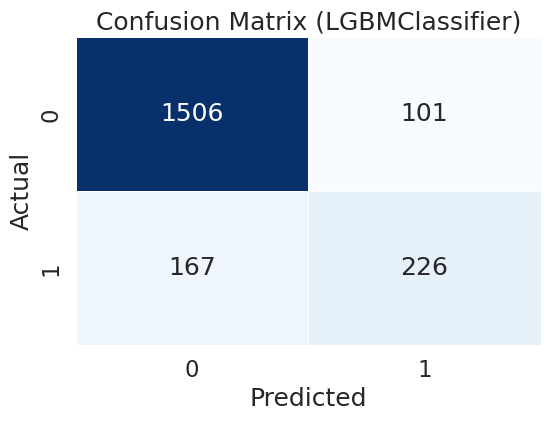

In [ ]:
# Create a confusion matrix for LGBMClassifier
conf_matrix_lgbm = confusion_matrix(y_test, y_pred_lgbm)


### **Neural Network Mode**
- **Use Adam Optimizer with learning_rate = 0.01**
- **Use 'accuracy', Precision, Recall, and F1Score as metrics, if you didn't call them you can see [this](https://keras.io/api/metrics/)**
- **Try to write the same architecture as shown in summary**

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

- **Try with epochs=100, batch_size=8, and validation_split=0.2**
- **Don't forget store the model and the history of the training process**

Epoch 1/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7251 - f1_score: 0.5477 - loss: 0.5392 - precision: 0.6797 - recall: 0.5133 - val_accuracy: 0.5895 - val_f1_score: 1.0000 - val_loss: 0.7773 - val_precision: 1.0000 - val_recall: 0.5895
Epoch 2/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7880 - f1_score: 0.5403 - loss: 0.4512 - precision: 0.7688 - recall: 0.6118 - val_accuracy: 0.7633 - val_f1_score: 1.0000 - val_loss: 0.4031 - val_precision: 1.0000 - val_recall: 0.7633
Epoch 3/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8047 - f1_score: 0.5480 - loss: 0.4296 - precision: 0.7895 - recall: 0.6587 - val_accuracy: 0.7043 - val_f1_score: 1.0000 - val_loss: 0.5751 - val_precision: 1.0000 - val_recall: 0.7043
Epoch 4/100
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8113 - f1_score: 0.5495 - loss: 0.4197 - precision: 0.7867 - recall: 0.6892 - val_accuracy: 0.6669 - val_f1_score: 1.0000 - val_loss: 0.5823 - val_precision: 1.0000 -

### **Model Evaluation**

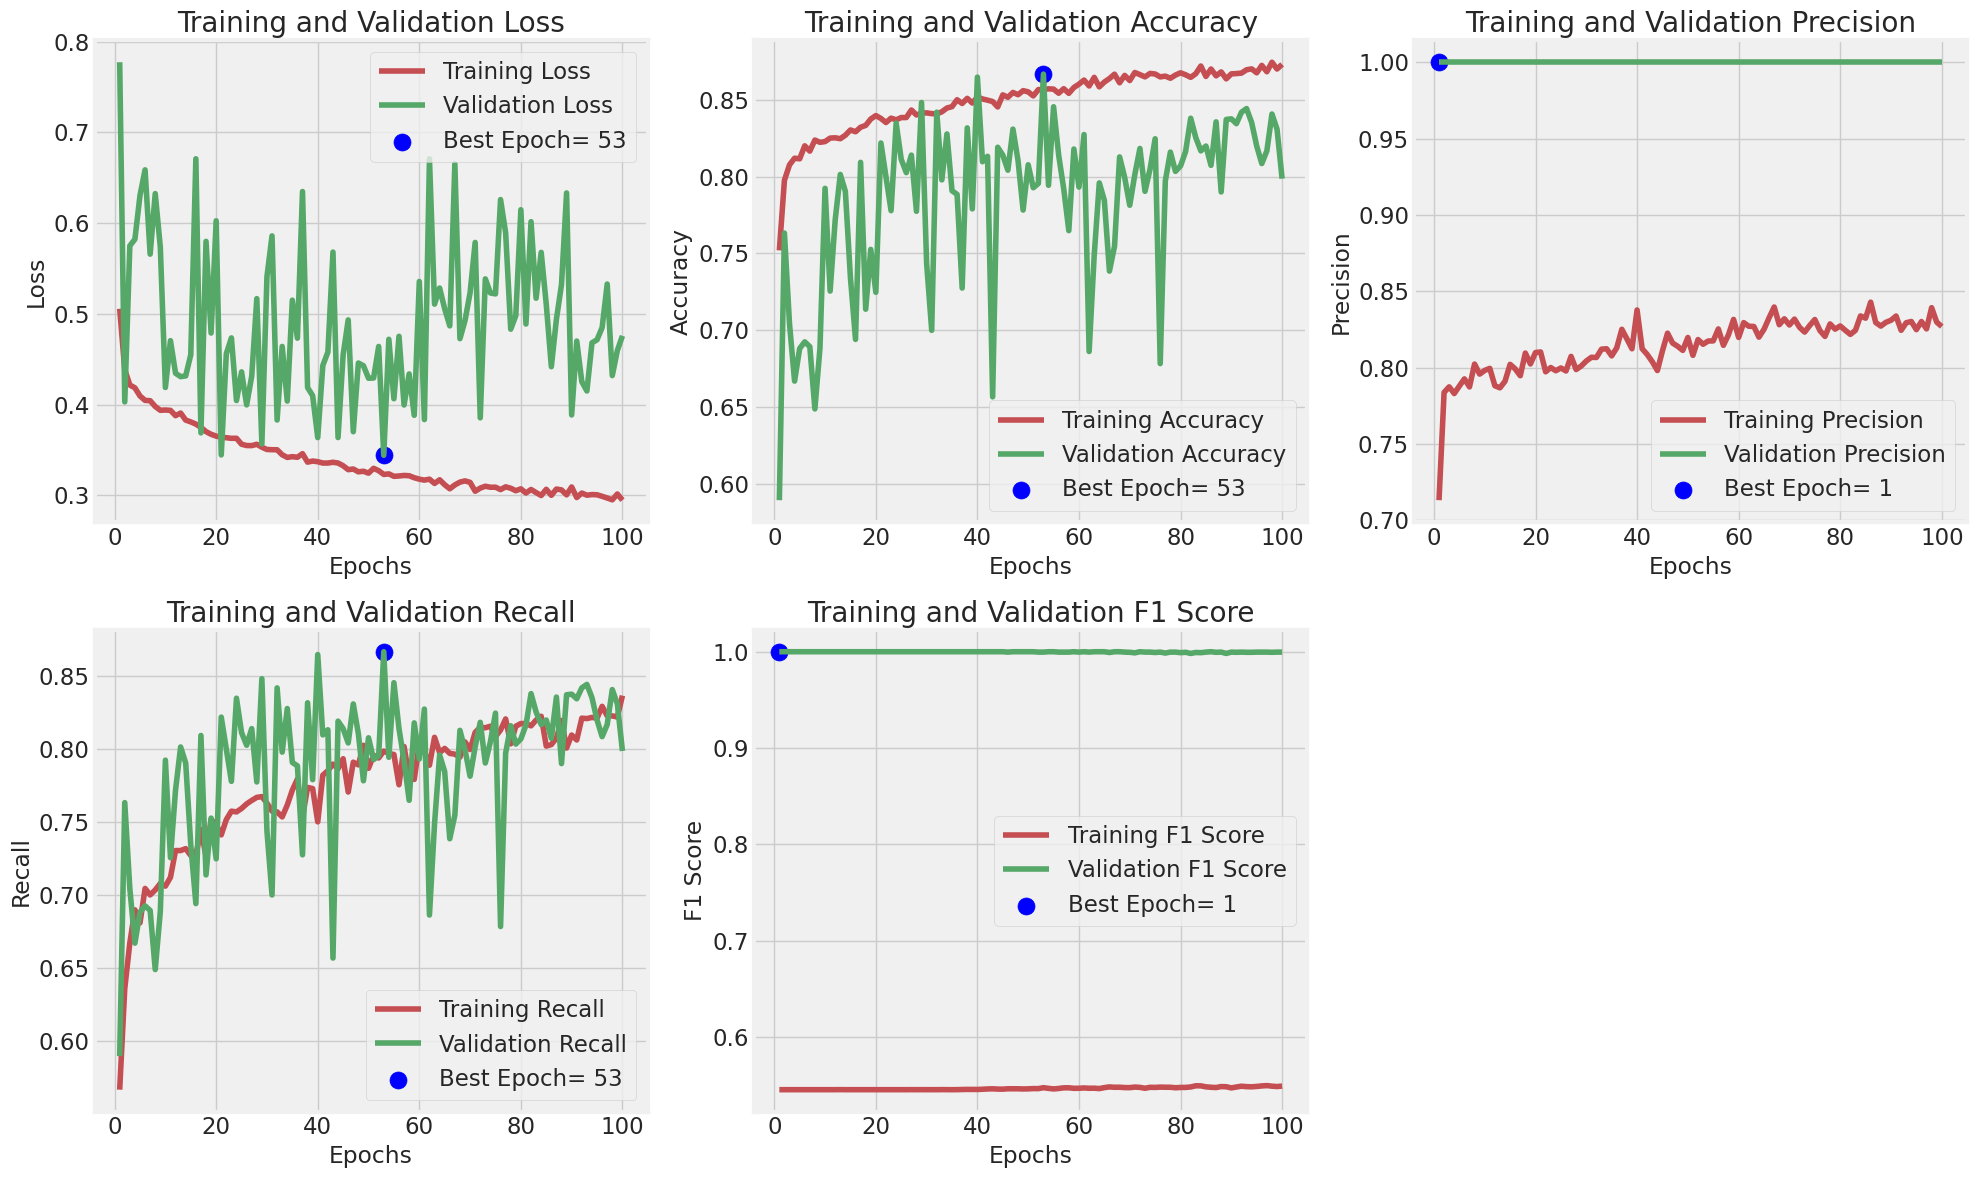

In [ ]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
tr_precision = history.history['precision']
tr_recall = history.history['recall']
tr_f1 = history.history['f1_score']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
val_precision = history.history['val_precision']
val_recall = history.history['val_recall']
val_f1 = history.history['val_f1_score']

# Find the best epochs for each metric
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

index_precision = np.argmax(val_precision)
precision_highest = val_precision[index_precision]

index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

index_f1 = np.argmax(val_f1)
f1_highest = val_f1[index_f1]

# Labels for the best epochs
loss_label = f'Best Epoch= {str(index_loss + 1)}'
acc_label = f'Best Epoch= {str(index_acc + 1)}'
precision_label = f'Best Epoch= {str(index_precision + 1)}'
recall_label = f'Best Epoch= {str(index_recall + 1)}'
f1_label = f'Best Epoch= {str(index_f1 + 1)}'

# Create Epochs list
Epochs = [i + 1 for i in range(len(tr_acc))]

# Plot training history
plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')

# Subplot for Loss
plt.subplot(2, 3, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training Loss')
plt.plot(Epochs, val_loss, 'g', label='Validation Loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Subplot for Accuracy
plt.subplot(2, 3, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Subplot for Precision
plt.subplot(2, 3, 3)
plt.plot(Epochs, tr_precision, 'r', label='Training Precision')
plt.plot(Epochs, val_precision, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, precision_highest, s=150, c='blue', label=precision_label)
plt.title('Training and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()

# Subplot for Recall
plt.subplot(2, 3, 4)
plt.plot(Epochs, tr_recall, 'r', label='Training Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Training and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()

# Subplot for F1 Score
plt.subplot(2, 3, 5)
plt.plot(Epochs, tr_f1, 'r', label='Training F1 Score')
plt.plot(Epochs, val_f1, 'g', label='Validation F1 Score')
plt.scatter(index_f1 + 1, f1_highest, s=150, c='blue', label=f1_label)
plt.title('Training and Validation F1 Score')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()

plt.tight_layout()
plt.show()


**This graph is not perfect, so try to reduce learning_rate decay**

In [ ]:
# show evaluation metrics for training

398/398 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8835 - f1_score: 0.4207 - loss: 0.2637 - precision: 0.7652 - recall: 0.7768
Train Loss: 0.31470414996147156
Train Accuracy: 0.8627281188964844
Train Precision: 0.907548189163208
Train Recall: 0.8077406883239746
Train F1Score: 0.6696526408195496


In [ ]:
# show evaluation metrics for testing

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8150 - f1_score: 0.3322 - loss: 0.5112 - precision: 0.5272 - recall: 0.6150
Test Loss: 0.5322808027267456
Test Accuracy: 0.8209999799728394
Test Precision: 0.5395033955574036
Test Recall: 0.6081424951553345
Test F1Score: 0.330522745847702


### **Evaluation**

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color: ##F0E68C ; font-size:100%; text-align:left">

<h3 align="left"><font color=brown>📊 Key Metrics:</font></h3>
    
- **`Accuracy:`**
    - Measures the overall correctness of the model (the percentage of correct predictions).
    - Accuracy is not the most important metric in imbalanced datasets, as it can be misleading. For example, predicting the majority class most of the time will give high accuracy but poor performance on the minority class (churners).


- **`Precision:`**
    - Precision answers the question: Of all the customers predicted to churn, how many actually churned?
    - High precision means fewer false positives (customers predicted to churn but actually don’t).


- **`Recall:`**
    - Recall answers the question: Of all the customers that actually churned, how many did the model correctly identify?
    - High recall means fewer false negatives (customers that churn but were predicted not to).

In [ ]:
Models = ['LogisticRegression', 'SVC', 'KNN', 'DecisionTreeClassifier', 'RandomForestClassifier', 'BaggingClassifier',
         'ExtraTreesClassifier', 'XGBoostClassifier', 'AdaBoostClassifier', 'CatBoostClassifier', 'LGBMClassifier', 'Neural Network']
Accuracy = [lr_acc, svc_acc, knn_acc, clf_acc, rf_acc, bag_acc, et_acc, xgb_acc, ada_acc, cat_acc, lgbm_acc, test_score[1]]
Precision = [lr_per, svc_per, knn_per, clf_per, rf_per, bag_per, et_per, xgb_per, ada_per, cat_per, lgbm_per, test_score[2]]
Recall = [lr_rec, svc_rec, knn_rec, clf_rec, rf_rec, bag_rec, et_rec, xgb_rec, ada_rec, cat_rec, lgbm_rec, test_score[3]]

models = pd.DataFrame(data={'Models': Models,'Accuracy': Accuracy, 'Precision': Precision, 'Recall': Recall})
models

,Models,Accuracy,Precision,Recall
0,LogisticRegression,0.7390,0.400922,0.664122
1,SVC,0.8820,0.828452,0.503817
2,KNN,0.7705,0.440217,0.618321
3,DecisionTreeClassifier,0.7430,0.411160,0.712468
4,RandomForestClassifier,0.7925,0.480565,0.692112
5,BaggingClassifier,0.7430,0.412698,0.727735
6,ExtraTreesClassifier,0.7415,0.408284,0.702290
7,XGBoostClassifier,0.8500,0.637168,0.549618
8,AdaBoostClassifier,0.8150,0.521336,0.715013
9,CatBoostClassifier,0.8415,0.578189,0.715013


- **The Next values will be changed after your training, so write your inference metrics**
- **The values of the Neural Network model is absant, so create it with yours**

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color: ##F0E68C ; font-size:100%; text-align:left">

<h3 align="left"><font color=brown>📊 Inference:</font></h3>
    
**After applying SMOTE, the overall results show a significant improvement in recall across many models, which means the models are now better at identifying `churners`. Here’s a breakdown of the results and the actions you can take:**


**Logistic Regression:**
- `Accuracy:` 0.7390, `Precision:` 0.4009, `Recall:` 0.6641
- `Insight:` Significant improvement in recall (from 0.201 to 0.664), meaning the model can now detect more churners. However, the trade-off is a lower precision, indicating more false positives.


**SVC:**
- `Accuracy:` 0.8820, `Precision:` 0.8285, `Recall:` 0.5038
- `Insight:` SVC maintains a high accuracy and precision, but its recall is moderate. It still misses a significant portion of actual churners.


**KNN:**
- `Accuracy:` 0.7705, `Precision:` 0.4402, `Recall:` 0.6183
- `Insight:` KNN shows a balance between precision and recall, but neither is particularly strong.


**Decision Tree Classifier:**
- `Accuracy:` 0.7430, `Precision:` 0.4112, `Recall:` 0.7125
- `Insight:` Strong recall (0.7125) with moderate precision, meaning the model detects most churners but misclassifies some non-churners.


**Random Forest Classifier:**
- `Accuracy:` 0.7685, `Precision:` 0.4463, `Recall:` 0.7405
- `Insight:` Good recall (0.7405), meaning it identifies many churners, but precision is lower.


**Bagging Classifier:**
- `Accuracy:` 0.7730, `Precision:` 0.4502, `Recall:` 0.7023
- `Insight:` Similar performance to the Decision Tree, with good recall but moderate precision.


**Extra Trees Classifier:**
- `Accuracy:` 0.7325, `Precision:` 0.3953, `Recall:` 0.6819
- `Insight:` Recall has improved significantly, but the model still has low precision.


**XGBoost Classifier:**
- `Accuracy:` 0.8500, `Precision:` 0.6372, `Recall:` 0.5496
- `Insight:` Balanced performance with decent precision and recall, but there's still room for improvement.


**AdaBoost Classifier:**
- `Accuracy:` 0.8150, `Precision:` 0.5213, `Recall:` 0.7150
`Insight:` Good recall with moderate precision, meaning it identifies most churners but also misclassifies some non-churners.


**CatBoost Classifier:**
- `Accuracy:` 0.8415, `Precision:` 0.5782, `Recall:` 0.7150
- `Insight:` CatBoost shows strong recall, meaning it's effectively identifying churners, but there’s still room to improve precision.


**LGBM Classifier:**
- `Accuracy:` 0.8660, `Precision:` 0.6844, `Recall:` 0.5903
`Insight:` LGBM continues to perform well, showing high precision and balanced recall, though recall could be improved further.

<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color: ##F0E68C ; font-size:100%; text-align:left">

<h3 align="left"><font color=brown>📊 Key Takeaways:</font></h3>
    
**Best Models for Recall before applying SMOTE:**
- `XGBoostClassifier` (Recall: 0.5318) and `CatBoostClassifier` (Recall: 0.4860) performed best in terms of recall, meaning they were able to identify more churners compared to other models. However, their recall values were still moderate, indicating that many churners were missed.


**Balanced Models before applying SMOTE:**
- `LGBMClassifier` (Precision: 0.7316, Recall: 0.5064) and `XGBoostClassifier` (Precision: 0.6372, Recall: 0.5318) provided a good balance between precision and recall. These models had relatively strong performance in identifying churners while maintaining moderate precision, making them strong overall candidates.


**Best Model for Precision before applying SMOTE:**
- `SVC` had the highest precision (0.8285), meaning it was the most accurate when predicting churners. However, it had lower recall (0.5038), meaning it missed a significant portion of churners.

---------------------------------

**Best Models for Recall after applying SMOTE:**
- `RandomForestClassifier` (Recall: 0.7405) and `DecisionTreeClassifier` (Recall: 0.7125) are the top performers in terms of recall, meaning they are identifying the highest number of churners. However, their precision is moderate, which means they also predict some non-churners as churners.

**Balanced Models after applying SMOTE:**
- `LGBMClassifier` and `CatBoostClassifier` are well-balanced between accuracy, precision, and recall, making them strong candidates for overall performance. They both have high accuracy and decent recall without sacrificing too much precision.

**Best Model for Precision after applying SMOTE:**
- `SVC` has the highest precision (0.8285), meaning it is very accurate when predicting churners. However, it has a moderate recall, meaning it may miss some churners.

$$\mathrm{Best \space Wishes..♡}$$